In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [3]:
filepath = os.path.join('..', 'data', 'processed', 'nyc_airbnb_cleaned.csv')
df = pd.read_csv(filepath)

##  Section 1: Price Architecture & Market Distribution

Before looking at locations, let's see how Airbnbs in NYC are priced. The plots below focus on the core market (listings under $1,000 a night) to find the typical "sweet spot" for a stay and show how much of a price premium you pay for an entire home versus a private room.

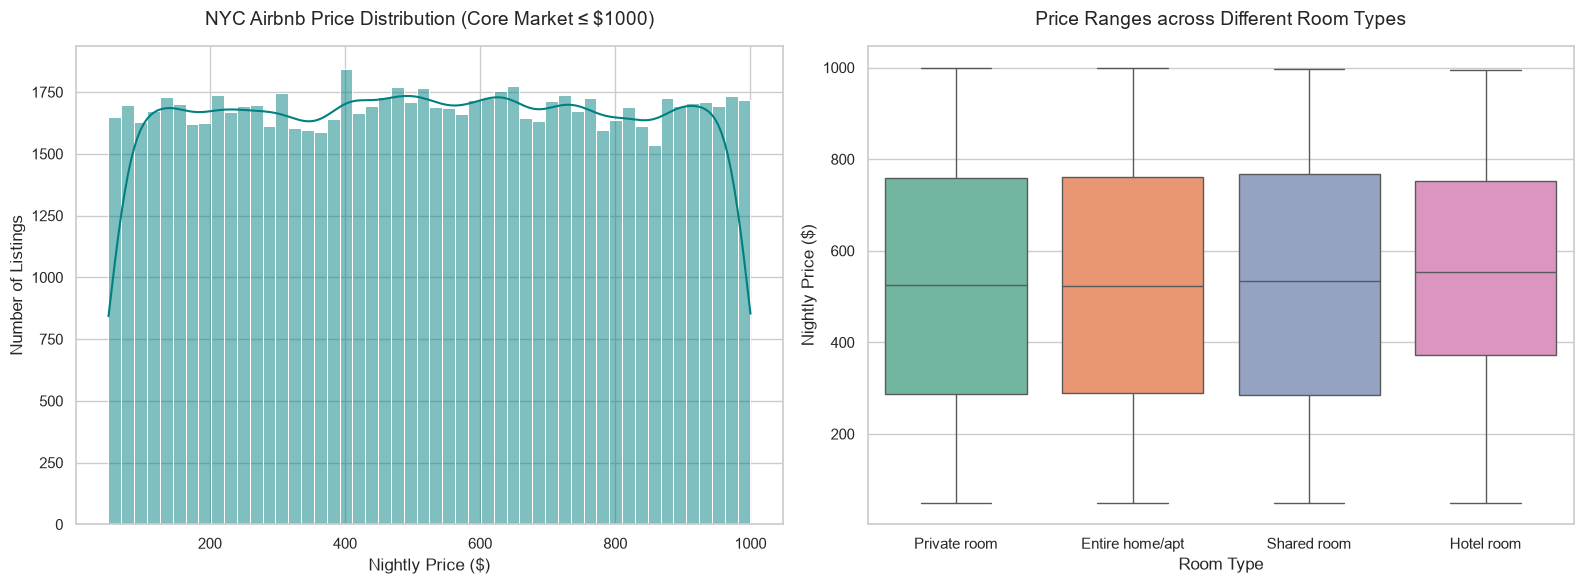

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df[df['price'] <= 1000]['price'], bins=50, kde=True, ax=axes[0], color='teal')
axes[0].set_title('NYC Airbnb Price Distribution (Core Market ≤ $1000)', fontsize=14, pad=15)
axes[0].set_xlabel('Nightly Price ($)', fontsize=12)
axes[0].set_ylabel('Number of Listings', fontsize=12)

sns.boxplot(data=df[df['price'] <= 1000], x='room type', y='price', ax=axes[1], hue='room type', palette='Set2')
axes[1].set_title('Price Ranges across Different Room Types', fontsize=14, pad=15)
axes[1].set_xlabel('Room Type', fontsize=12)
axes[1].set_ylabel('Nightly Price ($)', fontsize=12)

plt.tight_layout()
plt.show()


##  Section 2: Geographic Performance 

Location is everything in NYC. This section breaks down the data by borough to look at a classic market trade-off: **Listing Volume (Supply)** versus **Average Price (Value)**. This will show us which boroughs dominate the market in size, and which ones actually make the most money per night.

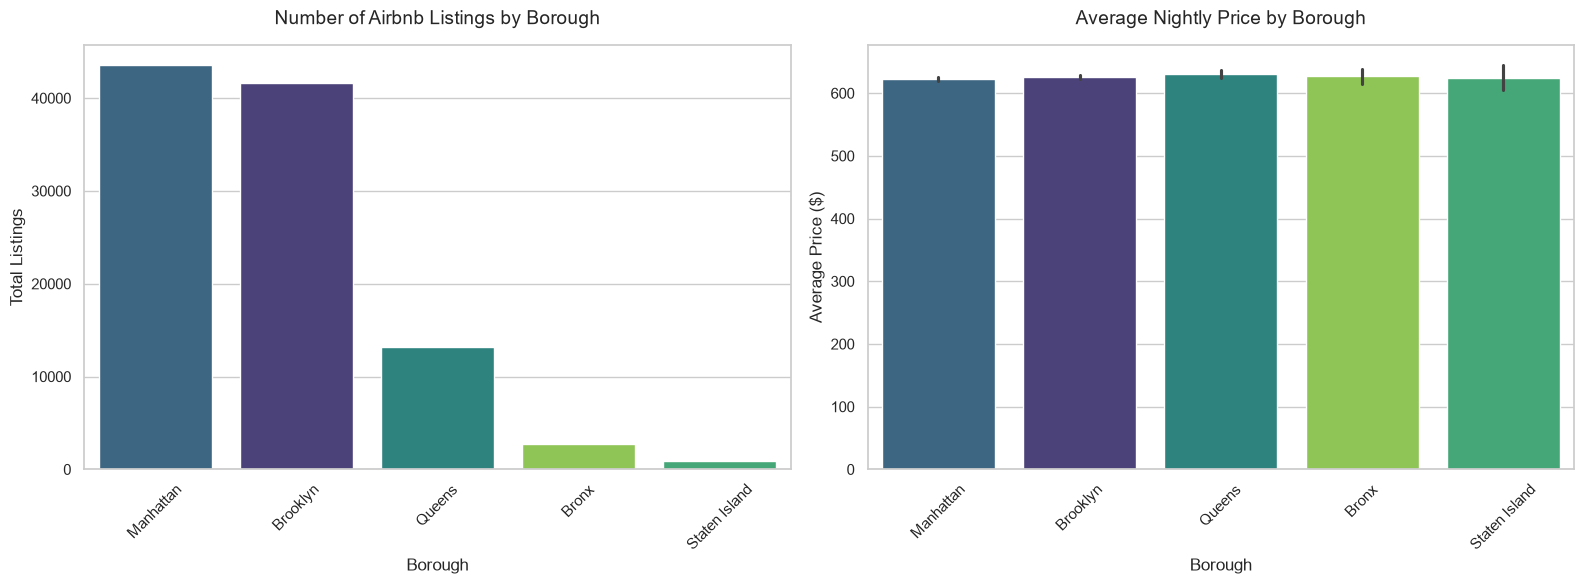

---  BOROUGH MARKET BREAKDOWN ---
                     total_listings   avg_price
neighbourhood group                            
Manhattan                     43545  622.579515
Brooklyn                      41614  626.419522
Queens                        13195  630.340053
Bronx                          2693  627.307464
Staten Island                   948  624.071730


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.countplot(data=df, x='neighbourhood group', ax=axes[0], hue='neighbourhood group', palette='viridis', 
              order=df['neighbourhood group'].value_counts().index)
axes[0].set_title('Number of Airbnb Listings by Borough', fontsize=14, pad=15)
axes[0].set_xlabel('Borough', fontsize=12)
axes[0].set_ylabel('Total Listings', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].get_legend().remove()


sns.barplot(data=df, x='neighbourhood group', y='price', ax=axes[1], hue='neighbourhood group', palette='viridis',
            order=df['neighbourhood group'].value_counts().index)
axes[1].set_title('Average Nightly Price by Borough', fontsize=14, pad=15)
axes[1].set_xlabel('Borough', fontsize=12)
axes[1].set_ylabel('Average Price ($)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].get_legend().remove()

plt.tight_layout()
plt.show()

print("---  BOROUGH MARKET BREAKDOWN ---")
borough_stats = df.groupby('neighbourhood group').agg(
    total_listings=('price', 'count'),
    avg_price=('price', 'mean')
).sort_values(by='total_listings', ascending=False)

print(borough_stats)

##  Section 3: Room Types & Market Share

Not all Airbnb listings offer the same experience. This section explores the product mix across New York City by looking at `room type`. We will check the overall percentage split of the inventory (e.g., Entire homes vs. Private rooms) and analyze exactly how much of a price premium hosts can charge when offering an entire property compared to a shared or private space.

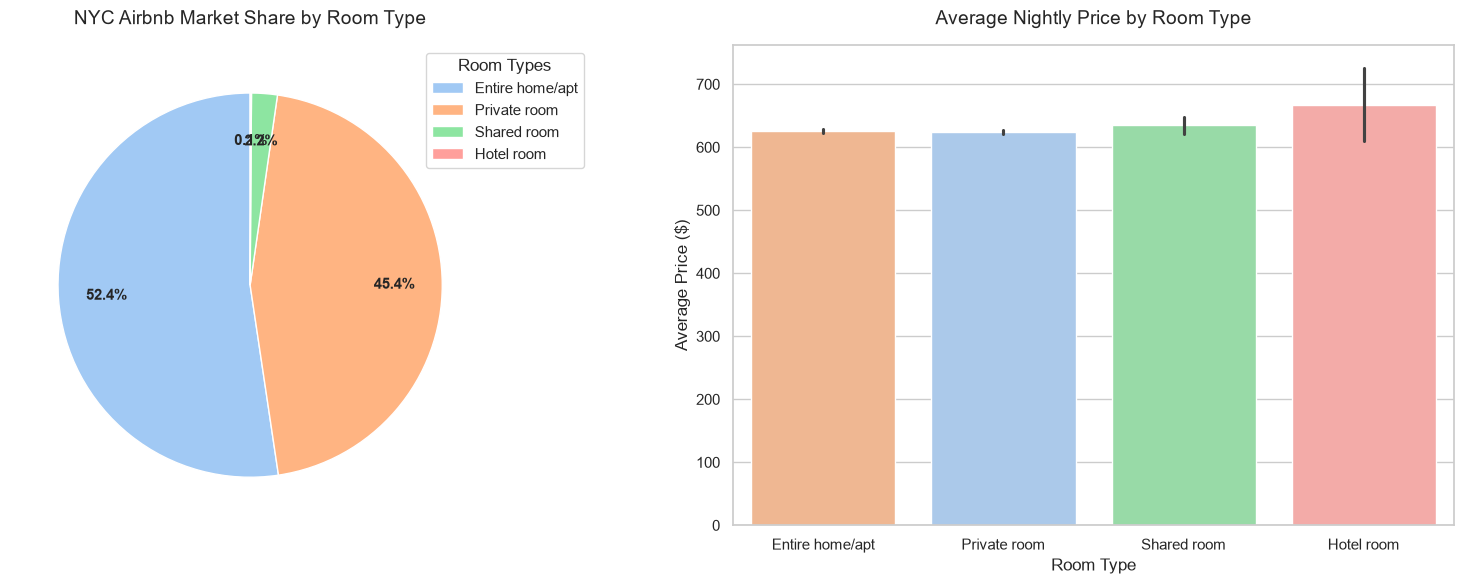

---  ROOM TYPE SUMMARY METRICS ---
                 total_listings   avg_price  median_price
room type                                                
Entire home/apt           53416  625.130186         624.0
Private room              46286  624.912414         623.0
Shared room                2207  635.290893         655.0
Hotel room                  115  666.391304         643.0


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

room_counts = df['room type'].value_counts()

axes[0].pie(room_counts, 
            labels=None, 
            autopct='%1.1f%%', 
            startangle=90, 
            colors=sns.color_palette('pastel'),
            pctdistance=0.75, 
            textprops={'fontsize': 11, 'weight': 'bold'})

axes[0].legend(room_counts.index, title="Room Types", loc="upper left", bbox_to_anchor=(0.85, 1))
axes[0].set_title('NYC Airbnb Market Share by Room Type', fontsize=14, pad=15)

sns.barplot(data=df, x='room type', y='price', ax=axes[1], hue='room type', palette='pastel',
            order=room_counts.index)
axes[1].set_title('Average Nightly Price by Room Type', fontsize=14, pad=15)
axes[1].set_xlabel('Room Type', fontsize=12)
axes[1].set_ylabel('Average Price ($)', fontsize=12)

plt.tight_layout()
plt.show()

print("---  ROOM TYPE SUMMARY METRICS ---")
room_stats = df.groupby('room type').agg(
    total_listings=('price', 'count'),
    avg_price=('price', 'mean'),
    median_price=('price', 'median')
).sort_values(by='total_listings', ascending=False)

print(room_stats)

##  Section 4: Booking Dynamics & Availability

Now that the data structure is solid, this final section digs into how listings operate. We will look at what the typical stay length actually looks like now that the extreme outliers are removed, and analyze listing activity using the number of reviews to see which room types generate the most guest interaction.

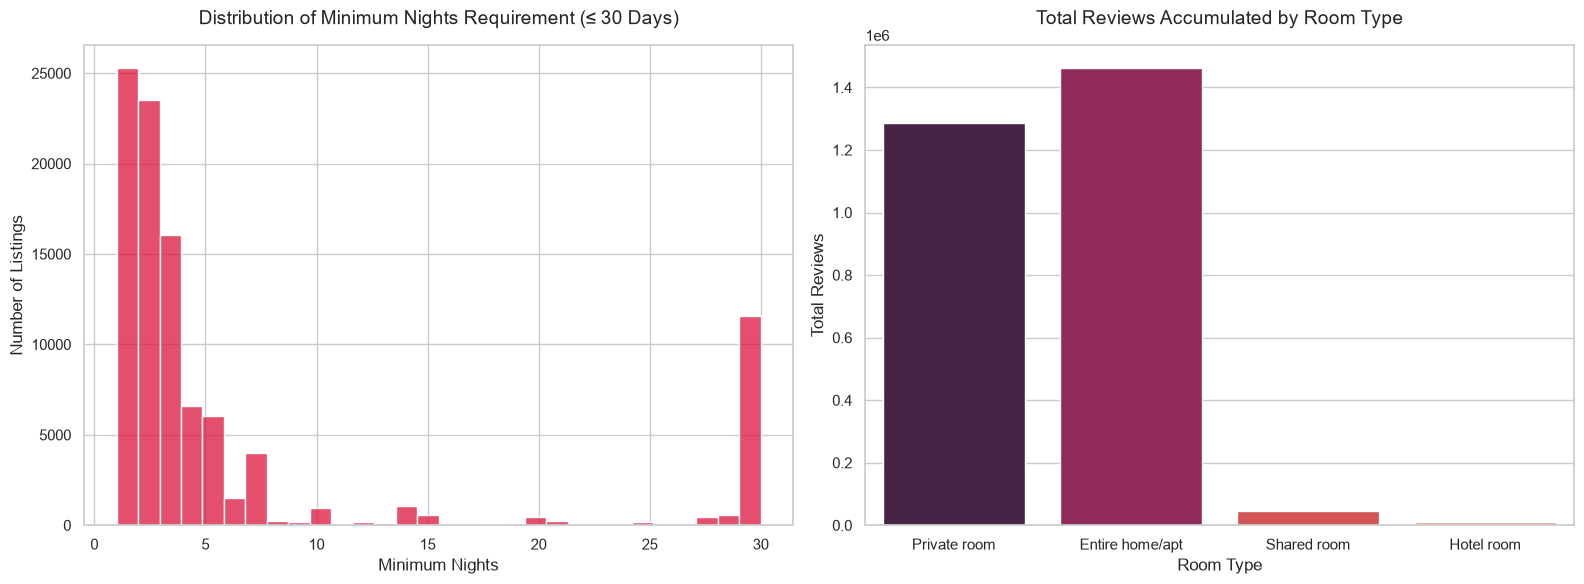

---  BOOKING & ACTIVITY METRICS ---
Most Common Minimum Nights (Mode): 1.0 night(s)
Median Minimum Nights: 3.0 night(s)
Total Reviews across all listings: 2,802,660.0


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(df[df['minimum nights'] <= 30]['minimum nights'], bins=30, kde=False, ax=axes[0], color='crimson')
axes[0].set_title('Distribution of Minimum Nights Requirement (≤ 30 Days)', fontsize=14, pad=15)
axes[0].set_xlabel('Minimum Nights', fontsize=12)
axes[0].set_ylabel('Number of Listings', fontsize=12)

sns.barplot(data=df, x='room type', y='number of reviews', ax=axes[1], hue='room type', palette='rocket', estimator=sum, errorbar=None)
axes[1].set_title('Total Reviews Accumulated by Room Type', fontsize=14, pad=15)
axes[1].set_xlabel('Room Type', fontsize=12)
axes[1].set_ylabel('Total Reviews', fontsize=12)


plt.tight_layout()
plt.show()

print("---  BOOKING & ACTIVITY METRICS ---")
print(f"Most Common Minimum Nights (Mode): {df['minimum nights'].mode()[0]} night(s)")
print(f"Median Minimum Nights: {df['minimum nights'].median()} night(s)")
print(f"Total Reviews across all listings: {df['number of reviews'].sum():,}")

In [8]:
df.head()

,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,price,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,966.0,193.0,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,142.0,28.0,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,620.0,124.0,3.0,0.0,NaN,0.00,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and..."
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,368.0,74.0,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,No rules specified
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,204.0,41.0,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th..."


In [9]:
df.dtypes

id                                  int64
NAME                                  str
host id                             int64
host_identity_verified                str
host name                             str
neighbourhood group                   str
neighbourhood                         str
lat                               float64
long                              float64
country                               str
country code                          str
instant_bookable                   object
cancellation_policy                   str
room type                             str
Construction year                 float64
price                             float64
service fee                       float64
minimum nights                    float64
number of reviews                 float64
last review                           str
reviews per month                 float64
review rate number                float64
calculated host listings count    float64
availability 365                  